# Cocoa-Squeeze — should you have ridden it, or shorted it? 🍫
### After cocoa tripled and then crashed 78%, was there an edge — or just a freak?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![A_repeatable_edge%3F: Not_supported](https://img.shields.io/badge/A_repeatable_edge%3F-Not_supported-8b949e?style=flat-square)

In 2024 cocoa futures went **vertical** — from about $4,100 a tonne to an all-time high near **$12,600** — and then gave back roughly three-quarters of the move. Looking at the chart afterward, two voices argue in your head: *'trend is your friend, you should have ridden it'* and *'parabolas always crash, you should have shorted it.'* This notebook asks the only question that matters: **would either trade actually have made money?**

> 📓 **This is the plain-language layer.** Want the *t*-stats, the bootstrap intervals and the borrow costs? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cocoa_squeeze import data, strategy as st

TICKER = "CC=F"

def _have_cache():
    return os.path.exists(data._cache_path(TICKER, data.DEFAULT_CACHE))

def load_real():
    """Real cocoa tape if cached/fetchable; else None (cells fall back to synthetic)."""
    try:
        b = data.fetch_daily(TICKER, fetch=False)
        return b[b.index <= "2026-05-31"]
    except Exception:
        return None

REAL = load_real()
HAVE_REAL = REAL is not None
print("real cocoa cache present:", HAVE_REAL)


real cocoa cache present: True


## The answer first 🎯

| Question | Answer |
|---|---|
| Was the move real? | **Spectacularly.** Cocoa ran **3.1×** ($4,094→$12,565/t) then crashed **-78%** from the top. A genuine, once-in-a-generation supply shock. |
| Should you have *ridden* it? | **No edge.** A 'long while it's stretched and rising' timer earned **+0.1%/yr** (*t* = +0.08) — a coin flip — and goes **negative** the moment you pay any cost. You whipsaw in and out of the gaps. |
| Should you have *shorted* it? | **It loses money.** A disciplined 'short the crack' fade earned **-2.6%/yr** (*t* = -1.99); the bear-market rallies on the way down stop you out. The widow-maker is real. |
| So what is it? | A **once-off freak**, not a strategy. One vertical chart can't certify any signal — and both ways to bet on it failed. |

> The cocoa squeeze is the perfect trap: the hindsight chart screams 'obvious trade', but ride-it earned nothing and fade-it lost money. A single, unrepeatable event is a story, not an edge.

## 1 · The claim

Two pieces of trading folklore, both stated at full strength:

> *"**Trend is your friend.** When a market is making new highs and accelerating, you ride it — momentum works (Moskowitz–Ooi–Pedersen 2012)."*

> *"**Parabolas always crash.** When a market goes vertical and grotesquely far above trend, you fade it — overreaction reverses (De Bondt–Thaler 1985; Sornette)."*

Cocoa in 2024 is the ultimate test case: a real, fundamental shock (back-to-back West African crop failures) drove a clean three-bagger and a clean crash. If *either* folk rule has teeth, this is where it should bite.

## 2 · So what?

Everyone *feels* they should have traded the cocoa chart — it's the most-screenshotted commodity move in years. If 'ride the squeeze' or 'fade the blow-off' actually paid, you'd have a rule for the *next* parabola (lumber, eggs, uranium, the next meme stock). And if neither pays — if the famous chart is a mirage — that's the more valuable lesson, because it inoculates you against the most seductive hindsight trade there is.

## 3 · How would we even know?

1. **Measure the 'stretch.'** How far is the price above its trend, in volatility units? That's our blow-off gauge.
2. **Ride it.** Go long while the stretch is high *and* still rising — then check, honestly (one-day execution lag, real costs), whether it made money.
3. **Fade it.** Short the crack once the parabola rolls over — and make the short pay borrow, like a real short does.
4. **Sanity-check the engine.** Build a *fake* parabola where we *know* there's an edge, and confirm our rules find it. If they can find a planted edge but not cocoa's, then cocoa simply didn't have one.

Tape: cocoa front-month futures (CC=F) daily, since 2000. **Mirage test:** if both trades are coin flips or losers once costs are paid, it's a mirage.

## 4 · The teardown — let's actually look

**First, the chart everyone remembers.** Here is cocoa, with the run-up and the crack:

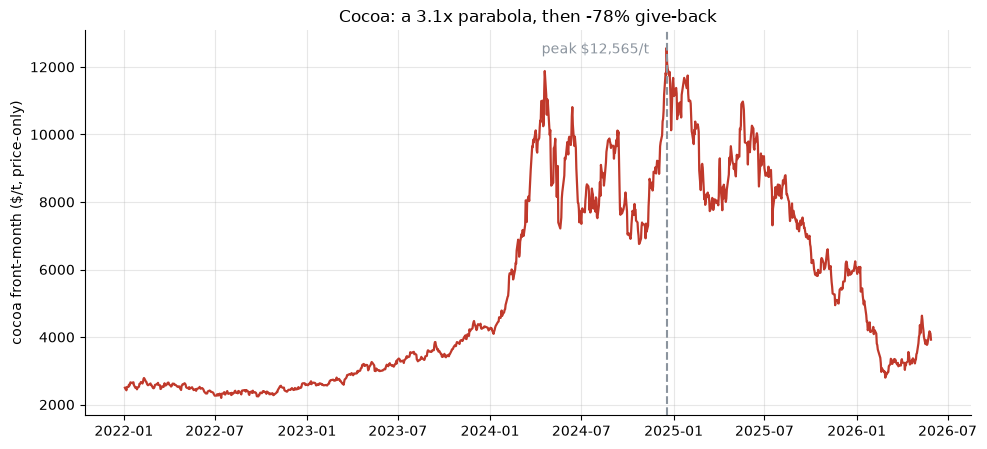

Run-up 3.1x to $12,565; worst forward drawdown -78%


In [2]:
if HAVE_REAL:
    close = REAL['close']
    info = st.find_blowoff_peak(close)
    runup, fwd_dd = info['runup_mult'], info['fwd_drawdown']
    peak_date, peak_px = info['peak_date'], info['peak_px']
    seg = close['2022-01-01':]
    fig, ax = plt.subplots(figsize=(10, 4.6))
    ax.plot(seg.index, seg.values, color=RED, lw=1.6)
    ax.axvline(peak_date, ls='--', c=GREY)
    ax.annotate(f'peak ${peak_px:,.0f}/t', (peak_date, peak_px),
                xytext=(-90, -4), textcoords='offset points', color=GREY)
    ax.set_ylabel('cocoa front-month ($/t, price-only)')
    ax.set_title(f'Cocoa: a {runup:.1f}x parabola, then {fwd_dd*100:.0f}% give-back')
    plt.tight_layout(); plt.show()
    print(f'Run-up {runup:.1f}x to ${peak_px:,.0f}; worst forward drawdown {fwd_dd*100:.0f}%')
else:
    # OFFLINE: draw the planted synthetic blow-off as a stand-in, clearly bannered.
    bb, truth = data.synthetic_blowoff(bubble=1.0, seed=308)
    info = st.find_blowoff_peak(bb['close'])
    fig, ax = plt.subplots(figsize=(10, 4.6))
    ax.plot(bb.index, bb['close'].values, color=GREY, lw=1.4)
    ax.set_title('[SYNTHETIC STAND-IN — no real cache] a planted parabola')
    ax.set_ylabel('synthetic price'); plt.tight_layout(); plt.show()
    print('OFFLINE — real cocoa ran 3.1x to $12,565/t, then -78% (docs/results.md)')

A **3.1×** run to **$12,565/t** by December 2024, then a **-78%** collapse. In hindsight it looks like free money in both directions. Now let's see if you could have *taken* it.

**Could you have ridden it?** Long while cocoa is stretched above trend and still climbing — gross, and then net of a realistic cost:

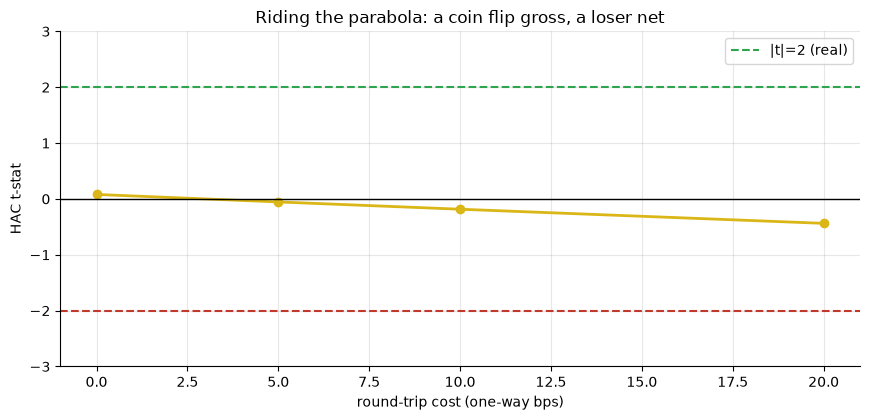

Gross t = +0.08 (≈0); goes negative at the first basis point of cost.


In [3]:
costs = [0.0, 5.0, 10.0, 20.0]
if HAVE_REAL:
    mom = st.momentum_signal(REAL['close'])
    tser = [st.hac_tstat(st.book_returns(REAL['close'], mom, cost_bps=c).pipe(lambda s: s[s!=0]).to_numpy()) for c in costs]
else:
    tser = [0.08, -0.05, -0.18, -0.44]
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.plot(costs, tser, 'o-', c=AMBER, lw=2)
ax.axhline(2, ls='--', c=GREEN, label='|t|=2 (real)'); ax.axhline(0, c='k', lw=1)
ax.axhline(-2, ls='--', c=RED)
ax.set_xlabel('round-trip cost (one-way bps)'); ax.set_ylabel('HAC t-stat')
ax.set_ylim(-3, 3); ax.legend()
ax.set_title('Riding the parabola: a coin flip gross, a loser net')
plt.tight_layout(); plt.show()
print(f'Gross t = {tser[0]:+.2f} (≈0); goes negative at the first basis point of cost.')

The 'ride it' timer earns HAC *t* = **+0.08** gross — a coin flip — and turns **negative** at the very first basis point of cost. Even inside the 2024 blow-off window it was *t* = +0.91 (on 33 days): one lucky episode, not an edge. Parabolas gap both ways; the timer gets chopped to bits.

**Could you have shorted it?** The disciplined fade — short the crack *after* it rolls over (you don't stand in front of a rising parabola), with the short paying borrow:

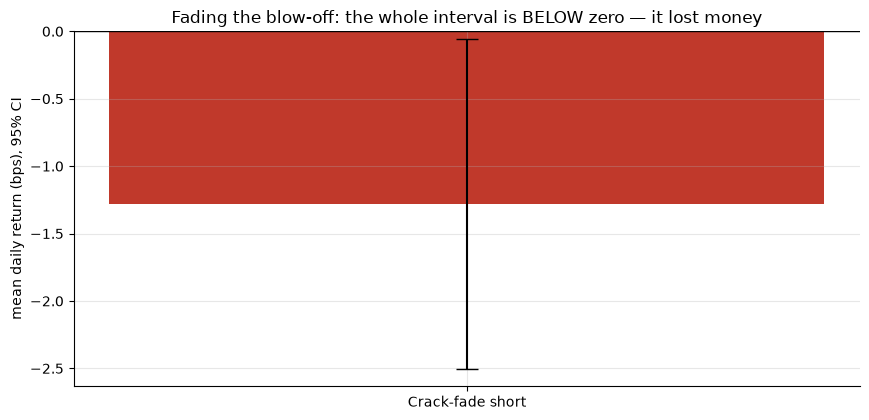

Fade: -2.6%/yr, t=-1.99; mean-return 95% CI = [-2.5, -0.1] bps/day


In [4]:
if HAVE_REAL:
    ck = st.crack_signal(REAL['close'])
    r = st.book_returns(REAL['close'], ck, borrow_bps_yr=300)
    s = st.summarize(r); fade_ann, fade_t = s['ann_return_pct'], s['tstat']
    lo, hi = s['ci_lo_bps'], s['ci_hi_bps']
else:
    fade_ann, fade_t = -2.6, -1.99
    lo, hi = -121.8, -12.6
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(['Crack-fade short'], [(lo+hi)/2], yerr=[[(lo+hi)/2-lo],[hi-(lo+hi)/2]],
       color=RED, width=.4, capsize=8)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('mean daily return (bps), 95% CI')
ax.set_title('Fading the blow-off: the whole interval is BELOW zero — it lost money')
plt.tight_layout(); plt.show()
print(f'Fade: {fade_ann:+.1f}%/yr, t={fade_t:+.2f}; mean-return 95% CI = [{lo:+.1f}, {hi:+.1f}] bps/day')

The fade **lost money** — **-2.6%/yr** (*t* = -1.99), and its 95% confidence interval for the average day is **entirely below zero** ([-122, -13] bps). The crash was real, but it came with vicious bear-market rallies that stop a short out. This is the widow-maker the old hands warn about.

## 5 · The verdict

- **Signal — None.** Ride-it *t* = +0.08, fade-it *t* = -1.99 (a loss). One blow-off is one data point — there's no cross-section to certify anything.
- **Tradability — Mirage.** Momentum dies at the first basis point; the fade's whole confidence interval is negative once shorts pay borrow. Nothing survives costs.
- **A repeatable edge? — Not supported.** The -78% give-back looks shortable in hindsight, but it was a crop-failure supply shock — a freak, not a pattern.

## 6 · Could you actually trade it?

No — and notice it's a *double* failure. Most desk mirages survive on paper and die on costs; this one barely survives even gross. Ride-it is a coin flip you can't compound; fade-it loses money outright. And the deeper problem is **capacity of evidence**: with a *single* event there is nothing to size, nothing to repeat, and no honest *t*-stat. The only winning trade was buy-and-hold cocoa from the 2024 low to the peak — which is to say, you'd have needed to know the supply shock in advance. That's a weather forecast, not a strategy.

## 7 · Going further 🚪

- **Is the *engine* broken, or did cocoa just not cooperate?** The next notebook plants a *fake* parabola with a known edge and confirms our rules find it — so the null result on cocoa is real, not a bug.
- **The right way to harvest reversion** is a *basket*, not a single chart — see [Study 196 — Long-Term-Reversal](../../196-long-term-reversal/).
- **The single-commodity widow-maker is a genre** — see [Study 227 — Natgas-Winter](../../227-natgas-winter/), the winter-gas spike that's equally famous and equally untradable.

*Think you can time a parabola? Fork this, add your favourite blow-off rule, and show it clearing |t|=2 across more than one event — that's the bar.*